<a href="https://colab.research.google.com/github/DilemmaFixer3/AI-2sem/blob/main/lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Епізод 1000: Успішність (останні 100) = 21%
Епізод 2000: Успішність (останні 100) = 56%
Епізод 3000: Успішність (останні 100) = 80%
Епізод 4000: Успішність (останні 100) = 91%
Епізод 5000: Успішність (останні 100) = 92%
Епізод 6000: Успішність (останні 100) = 92%
Епізод 7000: Успішність (останні 100) = 86%
Епізод 8000: Успішність (останні 100) = 92%
Епізод 9000: Успішність (останні 100) = 84%
Епізод 10000: Успішність (останні 100) = 95%

Сума всіх значень Q-таблиці: 24.082002000925115
--- Q-таблиця (значення очікуваної винагороди) ---
         Вліво (0)  Вниз (1)  Вправо (2)  Вгору (3)
Стан 0    0.531441   0.59049    0.590490   0.531441
Стан 1    0.531441   0.00000    0.656100   0.590490
Стан 2    0.590490   0.72900    0.590490   0.656100
Стан 3    0.656100   0.00000    0.469673   0.555435
Стан 4    0.590490   0.65610    0.000000   0.531441
Стан 5    0.000000   0.00000    0.000000   0.000000
Стан 6    0.000000   0.81000    0.000000   0.656100
Стан 7    0.000000   0.00000    0.000000   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


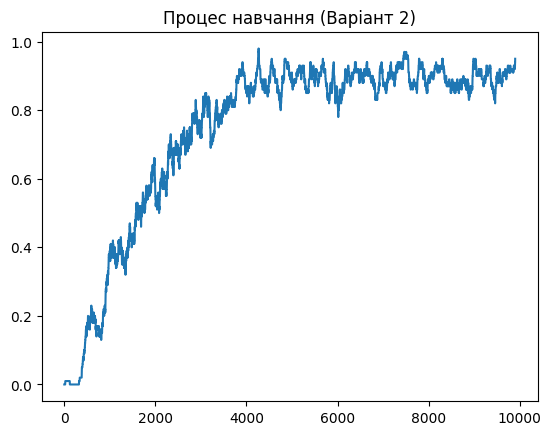

In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Створюємо середовище з лімітом кроків
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False, max_episode_steps=100)

def solve_frozen_lake():
    # Параметри Варіанту 2
    alpha = 0.3
    gamma = 0.9
    episodes = 10000 # Збільшено для гарантії

    nS = env.observation_space.n
    nA = env.action_space.n
    Q = np.zeros((nS, nA))

    epsilon = 1.0
    epsilon_decay = 0.9995
    min_epsilon = 0.1 # Мінімальне значення за варіантом

    rewards_per_episode = []

    for e in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # Вибір дії (Exploration vs Exploitation) [cite: 38, 39, 42, 45]
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Якщо агент впав у лунку, можна дати мікро-штраф (опційно),
            # але за правилами Q-learning використовуємо отриманий reward [cite: 59, 90]

            # Оновлення Q-значення [cite: 59, 90, 159, 187]
            old_value = Q[state, action]
            next_max = np.max(Q[next_state])

            # Формула: Q = Q + alpha * (R + gamma * maxQ' - Q)
            Q[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

            state = next_state
            total_reward += reward

        # Зменшуємо epsilon [cite: 46, 191]
        if epsilon > min_epsilon:
            epsilon *= epsilon_decay

        rewards_per_episode.append(total_reward)

        if (e + 1) % 1000 == 0:
            print(f"Епізод {e+1}: Успішність (останні 100) = {sum(rewards_per_episode[-100:])}%")

    return Q, rewards_per_episode

# Запуск
Q_final, history = solve_frozen_lake()

# ПЕРЕВІРКА: Якщо сума Q > 0, то все запрацювало!
print(f"\nСума всіх значень Q-таблиці: {np.sum(Q_final)}")

# Створюємо назви для колонок (дій) та індекси для рядків (станів)
action_names = ['Вліво (0)', 'Вниз (1)', 'Вправо (2)', 'Вгору (3)']
state_names = [f'Стан {i}' for i in range(len(Q_final))]

# Створюємо DataFrame
df_q_table = pd.DataFrame(Q_final, columns=action_names, index=state_names)

print("--- Q-таблиця (значення очікуваної винагороди) ---")
print(df_q_table)

if np.sum(Q_final) == 0:
    print("КРИТИЧНА ПОМИЛКА: Агент жодного разу не дійшов до цілі. Спробуйте запустити ще раз.")
else:
    # Вивід політики стрілками [cite: 617]
    arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    print("\nОптимальна політика:")
    for i in range(4):
        line = ""
        for j in range(4):
            s = i * 4 + j
            line += arrows[np.argmax(Q_final[s])] + " "
        print(line)

    # Графік
    plt.plot(np.convolve(history, np.ones(100)/100, mode='valid'))
    plt.title("Процес навчання (Варіант 2)")
    plt.show()

In [8]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Налаштування середовища (Варіант 2)
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False)

def epsilon_greedy_policy(Q, state, epsilon):
    """Стратегія epsilon-greedy"""
    if np.random.random() < epsilon:
        return np.random.randint(len(Q[state]))
    return np.argmax(Q[state])

def softmax_policy(Q, state, tau):
    """Стратегія Softmax (Boltzmann)"""
    # Q[state] / tau для обчислення імовірностей
    # tau (температура): чим вища, тим більш випадкові дії
    exp_q = np.exp(Q[state] / tau)
    probs = exp_q / np.sum(exp_q)
    return np.random.choice(len(Q[state]), p=probs)

def train_agent(strategy='epsilon_greedy', target_success_rate=0.9, max_episodes=5000):
    alpha = 0.3  # за варіантом [cite: 624]
    gamma = 0.9  # за варіантом [cite: 624]
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))

    rewards_history = []
    episodes_to_success = None

    # Параметри для стратегій
    epsilon = 1.0
    tau = 1.0
    decay = 0.999

    for e in range(max_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            if strategy == 'epsilon_greedy':
                action = epsilon_greedy_policy(Q, state, epsilon)
            else:
                action = softmax_policy(Q, state, tau)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Оновлення Q-таблиці [cite: 59, 90, 838]
            best_next_q = np.max(Q[next_state])
            Q[state, action] += alpha * (reward + gamma * best_next_q - Q[state, action])
            state = next_state

        rewards_history.append(reward)

        # Зменшення параметрів дослідження
        epsilon = max(0.1, epsilon * decay)
        tau = max(0.1, tau * decay)

        # Перевірка success rate (середнє за останні 100 епізодів) [cite: 621]
        if len(rewards_history) >= 100:
            current_sr = np.mean(rewards_history[-100:])
            if current_sr >= target_success_rate and episodes_to_success is None:
                episodes_to_success = e
                print(f"[{strategy}] Цільовий SR {target_success_rate} досягнуто на {e} епізоді")
                break

    return episodes_to_success, rewards_history

Початок порівняння стратегій...
[epsilon_greedy] Цільовий SR 0.8 досягнуто на 1628 епізоді
[softmax] Цільовий SR 0.8 досягнуто на 1586 епізоді


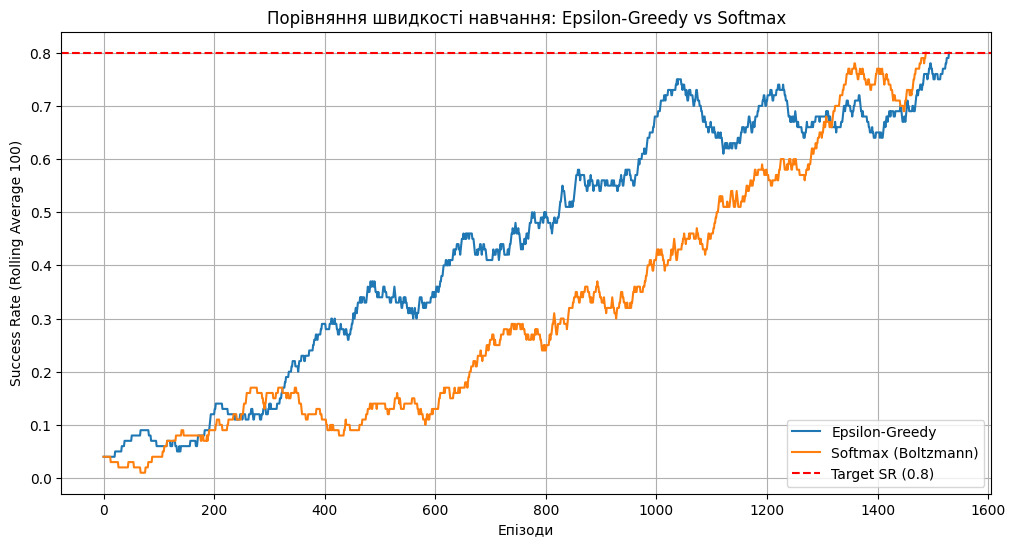


Підсумок:
Кількість епізодів до SR 0.8:
- Epsilon-Greedy: 1628
- Softmax: 1586


In [9]:
target_sr = 0.8  # Цільовий показник успішності

print("Початок порівняння стратегій...")
eps_episodes, eps_history = train_agent(strategy='epsilon_greedy', target_success_rate=target_sr)
soft_episodes, soft_history = train_agent(strategy='softmax', target_success_rate=target_sr)

# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.plot(np.convolve(eps_history, np.ones(100)/100, mode='valid'), label='Epsilon-Greedy')
plt.plot(np.convolve(soft_history, np.ones(100)/100, mode='valid'), label='Softmax (Boltzmann)')
plt.axhline(y=target_sr, color='r', linestyle='--', label=f'Target SR ({target_sr})')
plt.title(f"Порівняння швидкості навчання: Epsilon-Greedy vs Softmax")
plt.xlabel("Епізоди")
plt.ylabel("Success Rate (Rolling Average 100)")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nПідсумок:")
print(f"Кількість епізодів до SR {target_sr}:")
print(f"- Epsilon-Greedy: {eps_episodes if eps_episodes else 'Не досягнуто'}")
print(f"- Softmax: {soft_episodes if soft_episodes else 'Не досягнуто'}")

Початок дослідження впливу gamma...
Навчання для gamma = 0.6
Навчання для gamma = 0.8
Навчання для gamma = 0.95


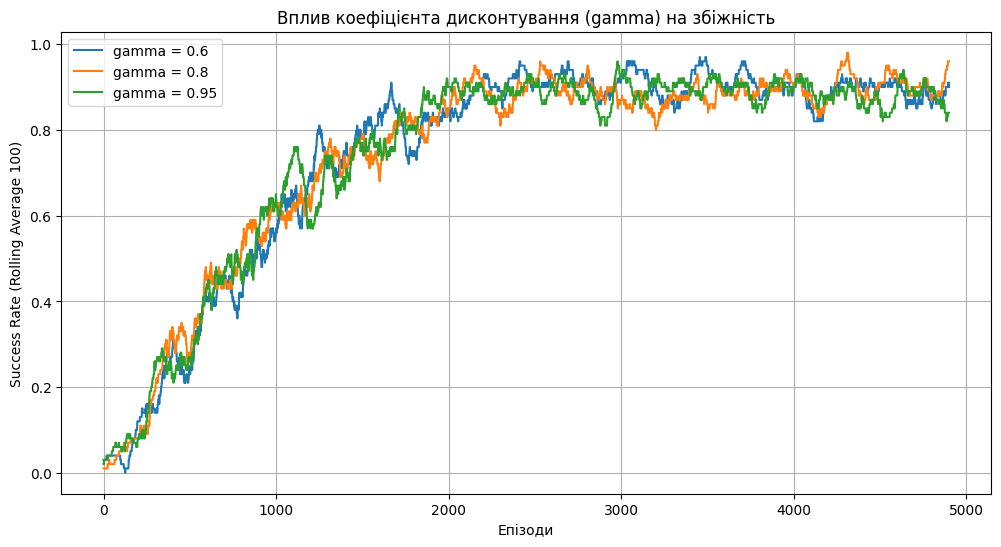

In [10]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Налаштування середовища
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False)

def train_with_gamma(gamma_value, episodes=5000):
    alpha = 0.3
    epsilon = 1.0
    epsilon_decay = 0.999
    min_epsilon = 0.1

    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    rewards_history = []

    for e in range(episodes):
        state, _ = env.reset()
        done = False

        while not done:
            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Оновлення Q-таблиці з конкретним gamma
            best_next_q = np.max(Q[next_state])
            Q[state, action] += alpha * (reward + gamma_value * best_next_q - Q[state, action])
            state = next_state

        rewards_history.append(reward)
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return rewards_history

# Дослідження трьох значень gamma
gammas = [0.6, 0.8, 0.95]
results = {}

print("Початок дослідження впливу gamma...")
for g in gammas:
    print(f"Навчання для gamma = {g}")
    results[g] = train_with_gamma(g)

# Візуалізація результатів
plt.figure(figsize=(12, 6))
for g in gammas:
    rolling_avg = np.convolve(results[g], np.ones(100)/100, mode='valid')
    plt.plot(rolling_avg, label=f'gamma = {g}')

plt.title("Вплив коефіцієнта дисконтування (gamma) на збіжність")
plt.xlabel("Епізоди")
plt.ylabel("Success Rate (Rolling Average 100)")
plt.legend()
plt.grid(True)
plt.show()

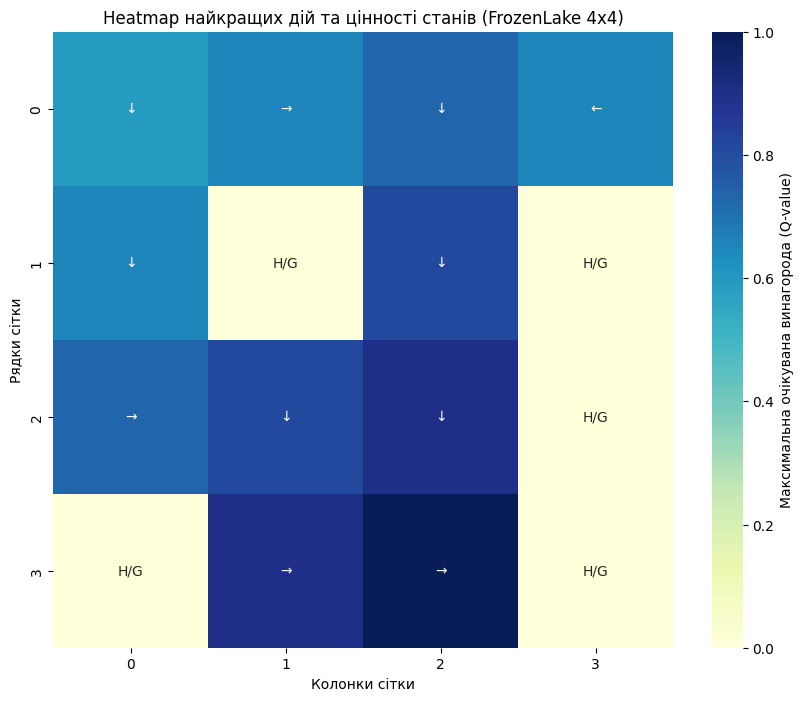

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import gymnasium as gym
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Використовуємо Q-таблицю, отриману після успішного навчання (Q_final)
def visualize_results(Q):
    # 1. Знаходимо максимальне значення Q для кожного стану (цінність стану)
    state_values = np.max(Q, axis=1).reshape(4, 4)

    # 2. Визначаємо найкращу дію для кожного стану (індекси)
    best_actions = np.argmax(Q, axis=1).reshape(4, 4)

    # Стрілки для візуалізації дій
    action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    # Створення маски для підписів дій на теплокарті
    action_labels = np.array([[action_arrows[a] if np.max(Q[i*4+j]) > 0 else "H/G"
                               for j, a in enumerate(row)]
                              for i, row in enumerate(best_actions)])

    # Побудова Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(state_values, annot=action_labels, fmt="", cmap="YlGnBu",
                cbar_kws={'label': 'Максимальна очікувана винагорода (Q-value)'})

    plt.title("Heatmap найкращих дій та цінності станів (FrozenLake 4x4)")
    plt.xlabel("Колонки сітки")
    plt.ylabel("Рядки сітки")
    plt.show()

# Запуск візуалізації
visualize_results(Q_final)

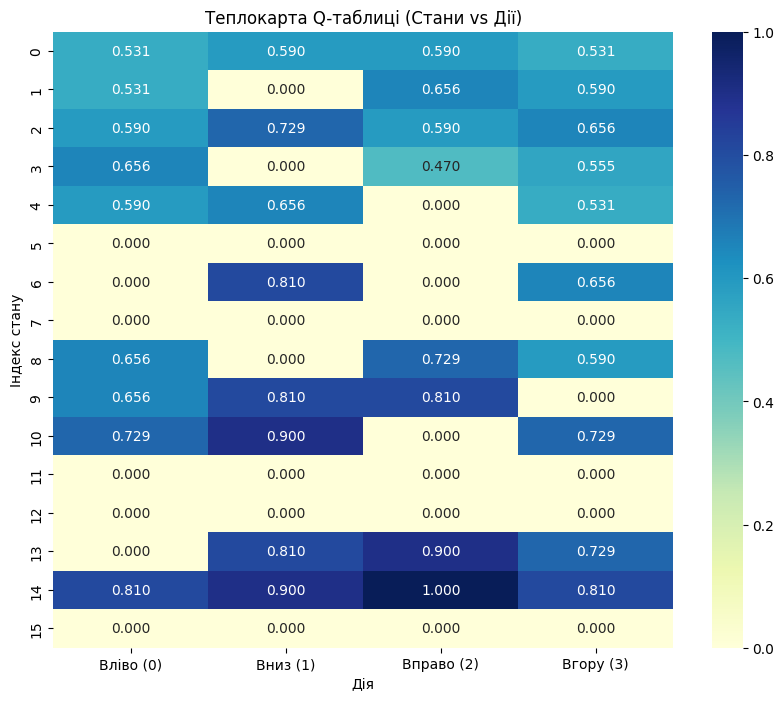

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(Q_final, annot=True, fmt=".3f", xticklabels=action_names, cmap="YlGnBu")
plt.title("Теплокарта Q-таблиці (Стани vs Дії)")
plt.ylabel("Індекс стану")
plt.xlabel("Дія")
plt.show()